In [1]:
# Import necessary libraries
import cv2 # OpenCV library for computer vision tasks
from matplotlib import pyplot as plt # Matplotlib for plotting graphs and displaying images
import numpy as np # Numpy for numerical operations (images are essentially 2D or 3D arrays)

In [2]:
# Load an image from the disk
# 'cv2.IMREAD_COLOR' loads the image in BGR format (Blue, Green, Red), which is standard for OpenCV.
# Note: Matplotlib uses RGB, so colors might look swapped if you plot BGR images directly with plt.
originalImage = cv2.imread('./apple.png', cv2.IMREAD_COLOR)

# Check if the image was loaded successfully
if originalImage is None:
    print("Error: Image not found. Check the path.")
else:
    # Uncomment to display the window using OpenCV (Works best in local scripts, not always in notebooks)
    # cv2.imshow('image', originalImage)
    # cv2.waitKey(0) # Waits indefinitely until a key is pressed
    # cv2.destroyAllWindows() # Closes the window

    # The .shape property returns a tuple: (Height, Width, Channels)
    print(f"Image Shape: {originalImage.shape}") # Height, Width, Color Channel (3 for BGR)

Image Shape: (900, 1200, 3)


In [3]:
# Resizing the image
scaledPercent = 50/100 # Define a scaling factor (50%)

# Calculate new dimensions
# Note: shape[0] is height (rows), shape[1] is width (columns)
newH = int(originalImage.shape[0] * scaledPercent)
newW = int(originalImage.shape[1] * scaledPercent)

# Resize the image using the calculated dimensions
resizedImage = cv2.resize(originalImage, (newW, newH))

# Display resized image details
print(f"Resized Image Shape: {resizedImage.shape}")

# cv2.imshow('Resized Image', resizedImage)
# cv2.waitKey(0)

Resized Image Shape: (450, 600, 3)


In [4]:
# Convert the BGR image to Grayscale
# Grayscale images have only one channel (intensity) instead of three (color).
# This reduces computational complexity for tasks where color isn't critical.
grayImage = cv2.cvtColor(resizedImage, cv2.COLOR_BGR2GRAY)

print(f"Grayscale Shape: {grayImage.shape}") # Note: No 3rd dimension for channels

Grayscale Shape: (450, 600)


In [5]:
# Manual Histogram Calculation
# A histogram represents the frequency of each pixel intensity value (0 to 255).

h = grayImage.shape[0] # Height
w = grayImage.shape[1] # Width

# Create an array of zeros to store the count for each pixel intensity (0-255)
intensityCounter = np.zeros(256, dtype=int)

# Iterate over every pixel in the grayscale image
# NOTE: Nested loops are slow in Python! In production, use cv2.calcHist([grayImage], [0], None, [256], [0, 256])
for i in range(h):
  for j in range(w):
    intensity = grayImage[i][j]
    intensityCounter[intensity] += 1

print("Histogram calculation complete.")

Histogram calculation complete.


In [6]:
# Histogram Equalization
# This method improves the contrast of an image by stretching out the intensity range.
# It's useful for images with poor contrast (too dark or too bright).

# Apply histogram equalization using OpenCV's built-in function
equalizedImage = cv2.equalizeHist(grayImage)

# Calculate the histogram for the equalized image manually for visualization
equalizedHist = np.zeros(256, dtype=int)

for i in range(equalizedImage.shape[0]):
  for j in range(equalizedImage.shape[1]):
    equalizedHist[equalizedImage[i][j]] += 1

print("Equalization complete.")

Equalization complete.


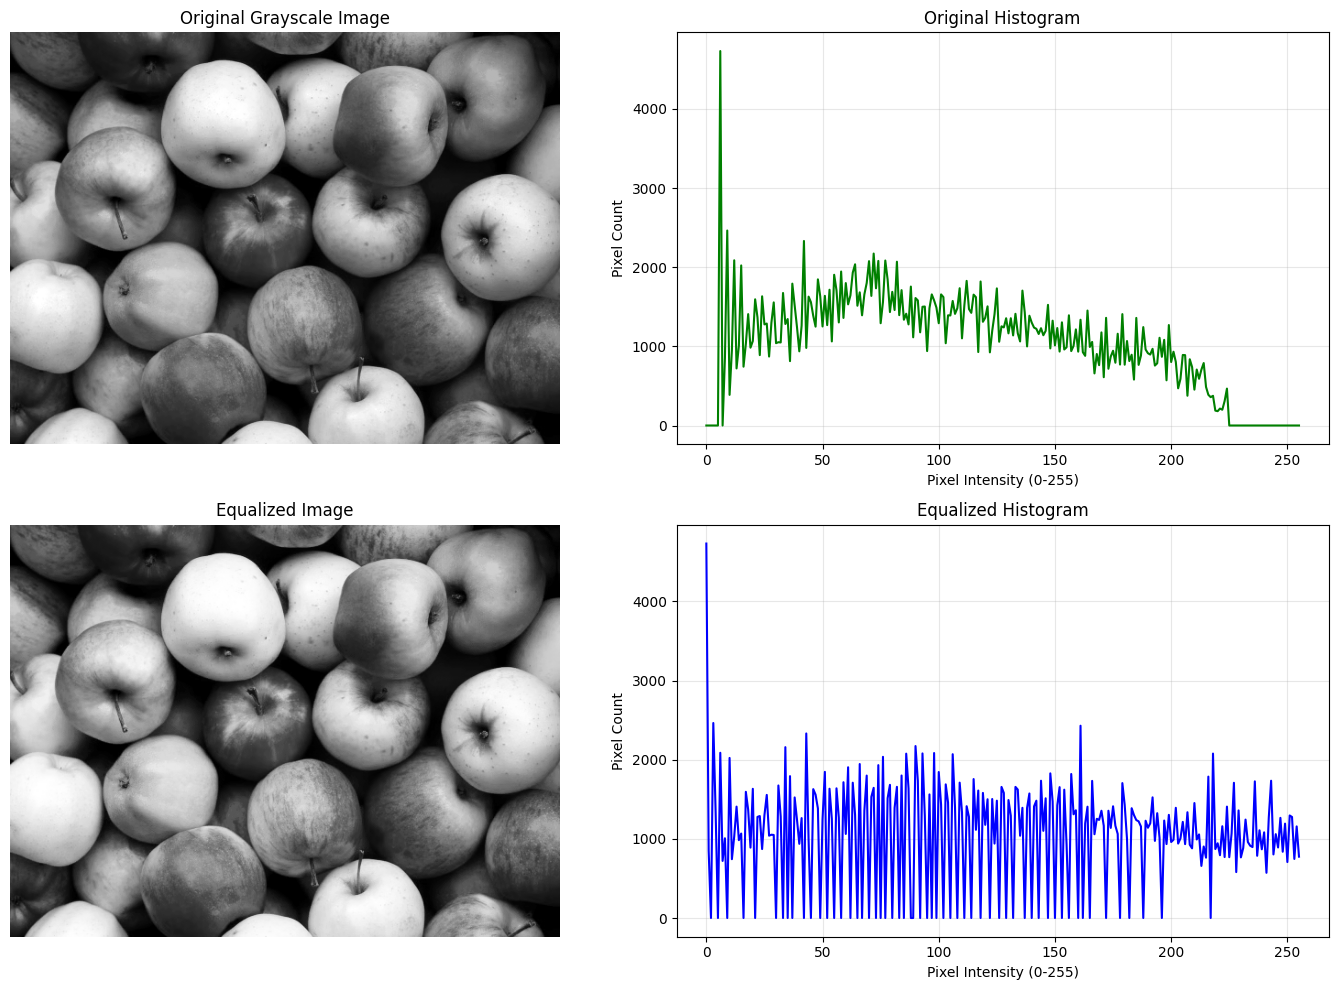

In [7]:
# Visualization using Subplots
# We will display the original image, original histogram, equalized image, and equalized histogram.

plt.figure(figsize=(14, 10)) # Set a larger figure size

# 1. Original Grayscale Image
plt.subplot(2, 2, 1) # 2 rows, 2 columns, position 1
plt.imshow(grayImage, cmap='gray')
plt.title('Original Grayscale Image')
plt.axis('off') # Hide axes for better visuals

# 2. Original Histogram
plt.subplot(2, 2, 2) # Position 2
plt.plot(intensityCounter, color='g')
plt.title('Original Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Pixel Count')
plt.grid(True, alpha=0.3)

# 3. Equalized Image
plt.subplot(2, 2, 3) # Position 3
plt.imshow(equalizedImage, cmap='gray')
plt.title('Equalized Image')
plt.axis('off')

# 4. Equalized Histogram
plt.subplot(2, 2, 4) # Position 4
plt.plot(equalizedHist, color='b')
plt.title('Equalized Histogram')
plt.xlabel('Pixel Intensity (0-255)')
plt.ylabel('Pixel Count')
plt.grid(True, alpha=0.3)

plt.tight_layout() # Adjust layout to prevent overlap
plt.show()